# Finite Difference Method for 1D Heat Equation

Solve:
\begin{align*}
  u_t  &= \alpha^2 u_{xx} \\
u(x,0) &= g(x)\\
u(0,t) &= A \\
u(L,t) &= B \\
(t,x) &\in \mathbb{R}^{+} \times [0,L]
\end{align*}
The iterative method to follow is:
$$ U_i^{j+1} = \lambda U_{i-1}^j + (1-2\lambda) U_i^j + \lambda U_{i+1}^j, $$
Donde $i,j = 1, ..., n-1$ y $\lambda = \dfrac{\alpha^2 k}{h^2}$

And it's associated matrix system is:
$$
\begin{pmatrix} 
U_1^{j+1} \\
\vdots \\
U_{n-1}^{j+1} \\
\end{pmatrix}
= 
\begin{pmatrix}
1-2\lambda & \lambda & 0 & \cdots & 0 \\
\lambda & 1-2\lambda & \lambda & \cdots & 0 \\
0 & \lambda & 1-2\lambda & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1-2\lambda
\end{pmatrix} 
\cdot 
\begin{pmatrix} 
U_1^{j} \\
\vdots \\
U_{n-1}^{j} \\
\end{pmatrix}

$$

With $U^0 = g(x)$, $U_0^j = A$, and $U_n^j = B$. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import matrix_power as mpow

from utils.visualization import matrix_plot, matrix_diff_plot
from utils.linalg import tridiag
from utils.utils import funcreload

# plt.style.use('dark_background')

## Example
For the sake of simplicty, let us consider $g(x) = \sin(\pi x), \, L = 1, \, \alpha = 1$ and $A = B = 0$. Thus, the solution for this problem is $u(x,t) = \sin(\pi x) \exp(-\pi^2 t)$ and the equation to be solved is:
\begin{align*}
u_t &= u_{xx},\\
u(x,0) &= \sin (\pi x)\\
u (0,t) &= 0\\
u (1,t) &= 0 \\
(t,x) &\in \mathbb{R}^{+} \times (0,1)
\end{align*}

In [2]:
def solution(x, t) -> np.float64:
    xx = np.sin(np.pi * x)
    tt = np.exp(- np.pi ** 2 * t)
    return xx * tt

def g(x) -> np.float64:
    return np.sin(np.pi * x)


L = T = alpha = np.float64(1)
A = B = np.float64(0)
n = 10
m = 500
xx = np.linspace(0, L, n)
tt = np.linspace(0, T, m)
h = L/n
k = T/m
lambda_ = (alpha**2 * k) / h**2

Solving the tridiagonal system

In [8]:
def solver(
        xx: np.ndarray,
        m: int, 
        param: float
) -> np.ndarray:
    n, = xx.shape

    # n-2 since we are not including boundary conditions
    right = tridiag(n-2, 1-2*param, param)
    res = np.empty([n-2, m])

    res[:, 0] = g(xx)[1:-1]
    for j in range(m-2):
        res[:, j+1] = right.dot(res[:, j])
    
    # include boundaries conditions
    boundary_a = np.full(m, A)
    boundary_b = np.full(m, B)
    result = np.vstack((boundary_a, res, boundary_b))
    return result


mat = solver(xx, m, lambda_)

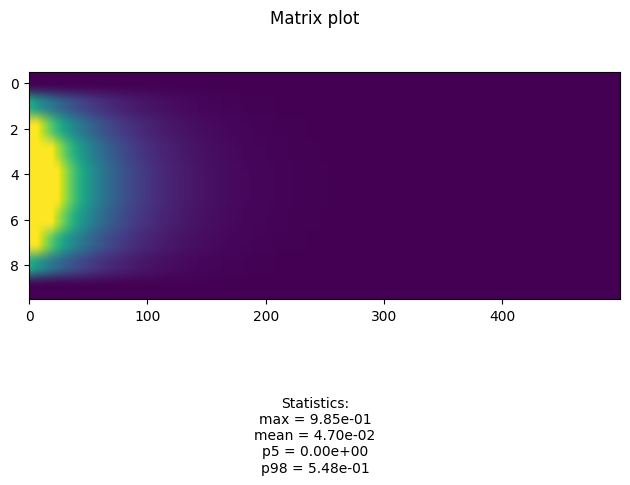

In [37]:
fig, _ = matrix_plot(mat, [5, 98])

## Possible Optimization?
Notice that the system can be written as $$U^{j+1} = \Lambda^{j}g(x_i).$$
Hence, assuming that it is faster to compute the power of a sparse array than computing iterative matrix multiplication at each step and assigning the returned value to an uninitalized array, this improves the system.

In [40]:
def solve_opti(
        xx: np.ndarray,
        size_t: int,
        lambda_: float,
) -> np.ndarray:

    lambda_mat = tridiag(n-2, 1-2*lambda_, lambda_)

    u_0 = g(xx)[1:-1]
    product = np.array([
        mpow(lambda_mat, i) @ u_0 
        for i in range(size_t)
    ])

    res = np.vstack([
        np.full(size_t, A),
        product.T,
        np.full(size_t, B)
    ])
    return res


mat_opti = solve_opti(xx, m, lambda_)

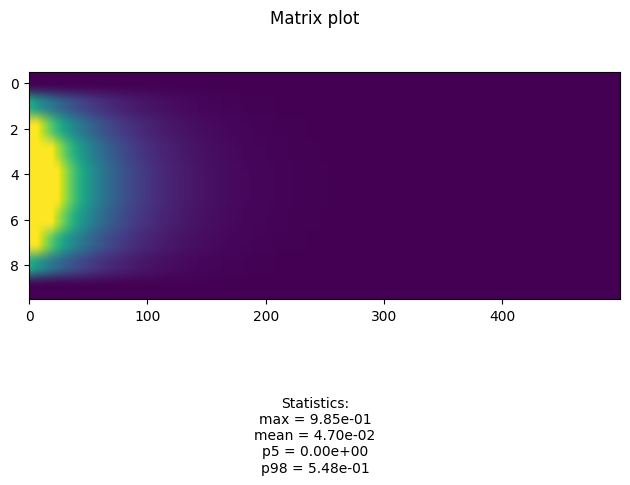

In [43]:
fig2 = matrix_plot(mat_opti, [5, 98])

We can check that the difference between the matrix is basically zero on average

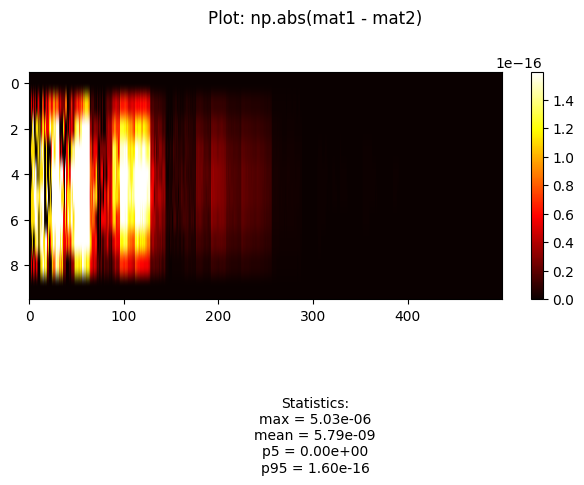

In [ ]:
fig3 = matrix_diff_plot(mat, mat_opti, [5, 95])

### Performance winner: `solve`
Checking performance comparison between `solve` and `solve_opti`. It seems that the power of a sparse array via `scipy.sparse.linal.matrix_power` can't outperform the simplicity of an iterative linear algebra schema.

In [85]:
from utils.time import map_timeit
from utils.stats import pprint_stats

p1 = lambda: solver(xx, m, lambda_)
p2 = lambda: solve_opti(xx, m, lambda_)

res = map_timeit([p1, p2], 20)
pprint_stats(res[0])
pprint_stats(res[1])

----------
Statistics
----------
min:		3.34e-03
median:		5.59e-03
mean:		5.29e-03
p95:		7.08e-03
max:		8.99e-03

----------
Statistics
----------
min:		2.07e-01
median:		2.90e-01
mean:		3.58e-01
p95:		5.63e-01
max:		6.02e-01

